Initialize Instruction Memory, Data Memory, and Program

In [60]:
import numpy as np
import matplotlib.pyplot as plt

#Simulation perameters
Max_steps = 10000
imem_size = 256
DMEM_size = 256
Num_reg = 16

signal_size = 1000

#Mem_port is used for structural hazards (MAY NOT USE)
mem_port = 3
pc = 0

#Initializing opcodes for easy access
oplist = ['nop','load','store','BEQ','MAC','Load_smp','Shift_buff','jmp','halt']
op = {}

for i in range(len(oplist)):
    op[oplist[i]] = i

#Initializing register names
reg = {}
for i in range(Num_reg):
    reg['R'+str(i)] = i

#Defining status dict
status = { "Running": 0,
           "Stalled": 1,
           "Done": -1
          }

#Defining stages for simuation
#Fetch, Decode, Execute,Memory Opperation, Writeback
stages = ["IF","ID","EX","MEM","WB"]

stage = {}
for i in range(len(stages)):
    stage[stages[i]] = i

dmem = np.zeros((DMEM_size,),dtype=np.int32)



Generate signals

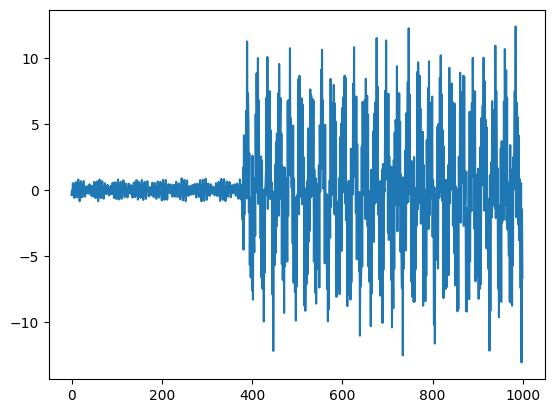

In [68]:
t = np.linspace(0, signal_size, num=signal_size)
s_norm = np.random.randn(signal_size)

n_comp = 5


#Generating random signal components
amps = np.random.uniform(0.01,20,n_comp)
freqs = np.random.uniform(0.01,200,n_comp)
phases = np.random.uniform(0,2*np.pi,n_comp)

for i in range(n_comp):
    s_norm += amps[i]*np.sin(2*np.pi*freqs[i]*t + phases[i])

#Normalze signal
s_norm = s_norm/np.max(s_norm)
#plt.plot(s_norm)

#Generating Earthquake signals:
amps = np.random.uniform(0.1,5,n_comp)
freqs = np.random.uniform(0.1,30,n_comp)
phases = np.random.uniform(0,2*np.pi,n_comp)

eq = np.zeros(signal_size)
for i in range(n_comp):
    eq += amps[i]*np.sin(2*np.pi*freqs[i]*t + phases[i])

#plt.plot(eq)

#To recreate an earthquake scenario, we'll take a portion of the earthquake signal, and add it to the noisy signal
eq_sample = np.copy(eq)
eq_start = np.random.randint(100,800)
eq_sample[0:eq_start] = 0
s_meassured = s_norm + eq_sample

plt.plot(s_meassured)

s_meassured = np.append(s_meassured,np.zeros(Max_steps-signal_size))


Creating Instruction and Pipeline Infrastructures

In [31]:
instruction_dtype = np.dtype([ #Assuming instructions follow: rd = opcode r1 r2
    ("disp","U40"),
    ("opcode",np.int32),
    ("rd",np.int32),
    ("r1",np.int32),
    ("r2",np.int32),
    ("im",np.int32),          #For other cases (i.e jump, branch, compare), im is used to store immediate values too
    ("status",np.int32),
])

imem = np.zeros(imem_size,dtype=instruction_dtype)
branch = 0
pipeline = np.zeros(5,dtype=instruction_dtype)

def Execute(inst,dmem):
  op = inst["opcode"]
  rd = inst["rd"]
  r1 = inst["r1"]
  r2 = inst["r2"]
  return 0 #TODO

def Check_Hazards(pipeline): #Only data and control hazards. Used AFTER Execute Function to count hazards, and stall when needed
  hazards = []
#Handling RAW Data hazard
  if (pipeline[stage['WB']]['rd'] in (pipeline[stage['EX']]['r1'], pipeline[stage['EX']]['r2'], pipeline[stage['ID']]['r1'], pipeline[stage['ID']]['r2'])):
    pipeline["status"] = status["Stalled"]
    pipeline[stage['WB']]["status"] = status['Running']
    hazards.append("RAW")

  #For now I'm assuming theres no instructions being executed out of order
  #If we do use an archetecture that does, we'll need to add cases for WAW and WAR

  #Checking for Control Hazards
  if pipeline[stage['EX']]["opcode"] == op['BEQ']:

    if branch: #If a branch occurs, flush the pipeline by replacing the instructions behind the branch with nop. CHANGE ME IF NEEDED!
      hazards.append("Control")
      pipeline[stage['IF']:stage['EX']]["opcode"] = op['nop']
      pipeline[stage['IF']:stage['EX']]["status"] = status['Done']


  #If there is a control hazard, the pipeline is flushed. This means data hazards are avoided as the nothing would be reading after writing until the next cycle
  if "Control" in hazards:
    return "Control"

  elif "RAW" in hazards:
    return "RAW"

  else:
    return "None"




Circular Buffer Code (Using OOP for multiple buffers if needed)

In [32]:
class circular_buffer:
  def __init__(self,size):
    self.size = size
    self.head = 0
    self.count = 0
    self.buffer = np.zeros(size)

  def push(self,x):
    self.buffer[self.head] = x
    self.head = (self.head + 1)%self.size
    return 1

#Tail pointer not needed as our continuous stream only needs to cycle data, not remove it. No pop functionality needed either

buff1 = circular_buffer(10)



Main Simulation (Without Accellerator Pipeline)
PROGRAM
   1. Update circular buffer with new meassurement (Load_smp)
   2. Preform MAC for 1st FIR (Could be done via vectorization)
   3. Second round of FIR
   4. Use STA/LTA
   6. Go to (1) until data is no longer received (Or maybe hault when Earthquake detected)
   
   Assigned Registers:
   - R1: pointer to circular buffer
   - R2: pointer to weights for FIR 1
   - R3: pointer to weights for FIR 2
   - R4: Accumulate reg for FIR 1
   - R5: Accumulate reg for FIR 2
   - R6: Flag register (Mostly to trigger Earthquake detection)
   
   - Other registers may be needed for pointing to memory or holding temporary results

Accellerator Layout
-

Streaming output truncated to the last 5000 lines.
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.03120985  0.2220314   0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
Step 63:
Input: 0.7886385162523076
[[-5.09897048e-01 -2.35841647e-01 -2.84274594e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-9.17188591e-02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 2.89669391e-04  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 2.88469069e-02  2.24574382e-01  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
Step 64:
Input: -0.043844575491184916
[[-0.23584165 -

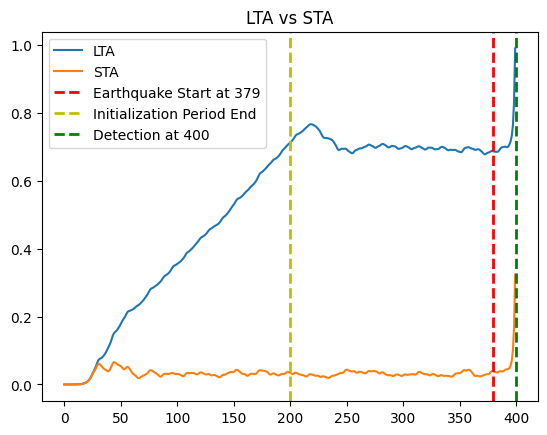

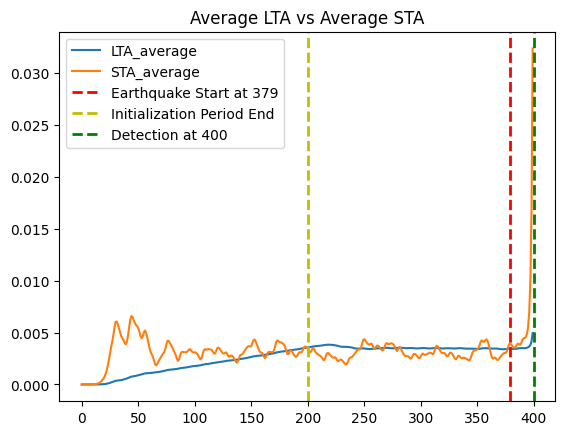

Earthquake Detected!
Detection Time: 21 cycles after earthquake started


In [84]:
#A few new types of circular buffers are created here. The first one has double the capacity. This buffer stores a second copy of the value being pushed, which allows the buffer to push out the values of the buffer in order
class double_buffer:
  def __init__(self,size):
    self.size = 2*size
    self.N = size
    self.head = 0
    self.count = 0
    self.buffer = np.zeros(self.size)

  def push(self,x):
    self.buffer[self.head] = x
    self.buffer[self.head + self.N] = x
    self.head = (self.head + 1)%self.N

  def get_alligned(self):
    return self.buffer[self.head:self.head + self.N]

#Another type used includes two additional buffers. This is used to keep track of the last filtered energy values placed into STA and LTA
class energy_buffer:
  def __init__(self,size):
    self.size = size
    self.head = 0
    self.count = 0
    self.buffer = np.zeros(self.size)

  def push(self,x):
    self.buffer[self.head] = x
    self.head = (self.head + 1)%self.size

  def get_delayed(self,k):
    return self.buffer[(self.head - k)% self.size]

#This code generates the weight coefficents for the BPF. These would be calculater before hand and stored in a register for easy access
def gen_BPF(f_upper,f_lower,fs,N):
  H = np.zeros(N,dtype=complex)
  f_content = np.fft.fftfreq(N,1/fs)

  for i, f in enumerate(f_content):
    if f_lower <= abs(f) <= f_upper:
      H[i] = 1
    else:
      H[i] = 0

  h = np.fft.ifft(H).real
  h = np.roll(h,N//2)
  return h


NL = 200 #Long term average size
Ns = 10 #Short term average size
Ne = 10 #Energy buffer size
num_acc_stages = 8

f_upper = 30
f_lower = 0.1
fs = 200
N = 32 #Input Buffer size

T = 2**2 #Threshold Value
detecion = 0 #An internal flag is used to trigger earthquake early warning system
stalled = 0 # Used to pause the cycle counter

in_buff = double_buffer(N)
energy_buff = double_buffer(Ne)
filtered_en_buff = energy_buffer(NL)
acc_pipeline = np.zeros((num_acc_stages,NL))

#Generate BPF weights
w1 = gen_BPF(f_upper,f_lower,fs,N)
w1 = w1[::-1]

#Smoothing filter that responds fast to sudden changes, but smooths out smaller ones
w2 = np.array([0.8**k for k in range(1,Ne+1)])
w2 = w2 / np.sum(w2)

'''For each clock cycle the accellerator will:
1) Load in the new data for the cicrular buffer
2) Send the data from the buffer into the first fiter stage (Using MAC and stored weights)
   - We need to make sure the data and the weights are alligned for this part
3) Send the filtered data into squarer to produce energy
4) Send energy into a second circular filter
5) Use second filter stage to smooth data
6) Push the smoothed data into another circular buffer
7) Reuse previous data to compute STA AND LTA'''

'''Assumptions:
1) All values within the vectorized registers are alligned
2) ...'''


step = 0
i = 0


#These values are stored in registers and get updated continuously
STA = 0
LTA = 0

LTA_vals = []
STA_vals = []
LTA_ave_vals = []
STA_ave_vals = []

while (step < Max_steps):

  #Save tasks in reverse order in order to not overwrite data

  #Eight Stage - Compareison
  if ((STA * NL > LTA*T *Ns) and (i>NL)):
    print("Earth Quake Detected!")
    acc_pipeline[7] = np.ones_like(acc_pipeline[7])
    acc_pipeline[7][0] = LTA
    acc_pipeline[7][1] = STA
    detecion = 1

  #Seventh Stage - Calculate LTA and STA
  LTA += filtered_en_buff.buffer[(filtered_en_buff.head - 1)%filtered_en_buff.size] - filtered_en_buff.get_delayed(NL)
  STA += filtered_en_buff.buffer[(filtered_en_buff.head - 1)%filtered_en_buff.size] - filtered_en_buff.get_delayed(Ns)
  LTA_vals.append(LTA)
  STA_vals.append(STA)
  LTA_ave_vals.append(LTA/NL)
  STA_ave_vals.append(STA/Ns)

  acc_pipeline[6][0] = STA
  acc_pipeline[6][1] = LTA
  #Sixth stage - Push smoothed value into circular filter
  acc_pipeline[5] = filtered_en_buff.buffer
  #Fifth stage - Smoothing filter, and storage into circular buffer 3
  acc_pipeline[4][0] = np.sum(acc_pipeline[3][:Ne]*w2)
  #Fourth stage - Save calculated energy into energy buffer
  acc_pipeline[3][:Ne] = energy_buff.get_alligned()
  #Third Stage - Calcularte energy (x^2)
  acc_pipeline[2][0] = np.square(acc_pipeline[1][0]) # Fix: Square the scalar output of the previous stage
  #2nd Stage - Bandpass FIR
  acc_pipeline[1][0] = np.sum(acc_pipeline[0][:N]*w1) # Fix: Use the first N elements of acc_pipeline[0]
  #1st Stage - Push values of input circular buffer
  acc_pipeline[0][:N] = in_buff.get_alligned() # Fix: Assign to a slice of acc_pipeline[0] to match shape
  step += 1

  #Update Buffer
  in_buff.push(s_meassured[i])
  energy_buff.push(acc_pipeline[2][0])
  filtered_en_buff.push(acc_pipeline[4][0])
  i += 1

  print(f"Step {i}:")
  print(f'Input: {s_meassured[i-1]}')
  print(acc_pipeline)

  if (detecion == 1):
    break



#Plotting Results
plt.title("LTA vs STA")
plt.plot(LTA_vals,label='LTA')
plt.plot(STA_vals,label='STA')
plt.axvline(x=eq_start, color='r', linestyle='--', linewidth=2,label=f'Earthquake Start at {eq_start}')
plt.axvline(x=NL, color='y', linestyle='--', linewidth=2,label='Initialization Period End')
plt.axvline(x=step, color='g', linestyle='--', linewidth=2,label=f'Detection at {step}')
plt.legend()
plt.show()

plt.title("Average LTA vs Average STA")
plt.plot(LTA_ave_vals,label='LTA_average')
plt.plot(STA_ave_vals,label='STA_average')
plt.axvline(x=eq_start, color='r', linestyle='--', linewidth=2,label=f'Earthquake Start at {eq_start}')
plt.axvline(x=NL, color='y', linestyle='--', linewidth=2,label='Initialization Period End')
plt.axvline(x=step, color='g', linestyle='--', linewidth=2,label=f'Detection at {step}')
plt.legend()
plt.show()

if (detecion == 1):
  print("Earthquake Detected!")
  print(f'Detection Time: {step-eq_start} cycles after earthquake started')

